<h1 align="center">
  <span style="color: purple;"> EDA </span>
</h1>

### Table of contents

[1. Overview](#1) <br>
[2. Anális de Datos](#2) <br>
[3. Setup](#3) <br>
[4. Loading data](#4) <br>
[5. Data Quality](#5) <br>
[6. Feature distributions](#6) <br>
[7. Feature scale comparisson](#7) <br>
[8. Correlation analysis](#8) <br>
[9. Temporal structure](#9) <br>
[10. Validation Anomaly Distributions](#10) <br>
    &emsp;&emsp; [10.1. Where are the anomalies?](#10.1) <br>
    &emsp;&emsp; [10.2. Compare normal vs anomalous distributions](#10.2) <br>
    &emsp;&emsp; [10.3. Anomalies over the feature space](#10.3) <br>
[11. Summary](#2) <br>


<a id="1"></a>
<h2 align="center">
  <span style="color: #440E03;">1. Overview </span>
</h2>


This project uses sequential server measurements with **11 features**.

The available datasets have different roles:

| Dataset | Role | Labels |
|---|---|---|
| `X_train` | Model training | Assumed mostly normal |
| `X_val`, `y_val` | Validation and model selection | Contains normal and anomalous observations |
| `X_test`, `y_test` | Final evaluation | Completely held out |

The training data is used to characterize the normal operating behavior that anomaly detection models are expected to learn.

The validation set is used during development to investigate anomaly-detection behavior, compare approaches, and make modeling decisions.

The test set is **completely held out** during exploratory analysis and model development. It will only be used for the final evaluation of the selected pipeline.

---

<b> <font color='blue'> <h3> Temporal assumption </h3> </font></b>

The available arrays do not contain an explicit timestamp.

For this project, we assume that **row order can reasonably be interpreted as an implicit temporal ordering**.

The observations can therefore be represented as:

$$
x_1, x_2, \ldots, x_T
$$

where consecutive rows represent consecutive observations in the underlying sequence.

This assumption is important because later stages of the project may use temporal windows and sequence models. The EDA will therefore examine both the marginal feature distributions and the behavior of observations across their original ordering.

---


<b> <font color='blue'> <h3> Questions to answer </h3> </font></b>

**1. Feature Structure**

- What are the 11 server variables?
- What are their ranges, distributions, and basic summary statistics?
- Are there missing values?
- Are there constant or near-constant features?
- Are there obviously problematic or implausible values?

**2. Scale and Dependence**

- How different are the feature scales?
- Are some features strongly correlated or potentially redundant?
- Does the feature space suggest that scaling may be important?
- Is there evidence that dimensionality reduction could be useful?

**3. Temporal Structure**

- Do feature values exhibit meaningful structure along the observation order?
- Are there trends, shifts, or other temporal patterns?
- Do consecutive observations appear sufficiently related to motivate temporal windows?
- Does the dataset exhibit characteristics that distinguish it from an i.i.d. tabular dataset?

**4. Anomaly Behavior**

Using the validation labels:

- How are anomalies distributed throughout the validation sequence?
- Are anomalies isolated or clustered?
- Do anomalous observations appear to have different feature behavior?
- Which features show the largest differences between normal and anomalous observations?

---

<b> <font color='blue'> <h3> Connection to modeling decisions </h3> </font></b>

The purpose of this EDA is not to select a model directly.

Instead, it provides evidence that can inform subsequent design decisions, particularly:

- **Feature scaling** — whether substantially different feature scales could affect model behavior.
- **Dimensionality reduction** — whether the 11-dimensional feature space contains strong redundancy or a lower-dimensional structure.
- **Temporal windowing** — whether neighboring observations exhibit meaningful dependence.
- **Sequence models** — whether the observed temporal structure is sufficiently meaningful to justify explicitly modeling sequences.

These decisions should be based on the observed characteristics of the data rather than assumed in advance.

---

<b> <font color='blue'> <h3> Data Leakage Boundary </h3> </font></b>

**The test set must not be used for exploratory decisions.**

In particular, `X_test` and `y_test` will NOT be used to:

- choose preprocessing methods;
- choose window sizes or strides;
- identify useful features;
- determine anomaly thresholds;
- select models;
- tune hyperparameters;
- interpret anomaly behavior in a way that influences the final pipeline.

The validation set is available for development and model selection.

The test set remains untouched until the final evaluation.

The intended workflow is:

```
X_train
   │
   ├── Understand normal operating data
   └── Fit training-dependent preprocessing/models
             │
             ▼
X_val + y_val
   │
   ├── Analyze anomaly behavior
   ├── Compare modeling choices
   └── Select the final pipeline
             │
             ▼
X_test + y_test
   │
   └── Final evaluation only
```  

<a id="2"></a>
<h2 align="center">
  <span style="color: #440E03;">2. Setup</span>
</h2>

In [44]:
from pathlib import Path
import numpy as np

import pandas as pd
import matplotlib.pyplot as plt

import seaborn as sns

from statsmodels.graphics.tsaplots import plot_acf

PROJECT_ROOT = Path.cwd().parent


<a id="3"></a>
<h2 align="center">
  <span style="color: #440E03;">3. Loading data</span>
</h2>

In [8]:
X_train = np.load(PROJECT_ROOT / "data/servers/X_part2.npy")
X_val = np.load(PROJECT_ROOT / "data/servers/X_val_part2.npy")
y_val = np.load(PROJECT_ROOT / "data/servers/y_val_part2.npy")

In [9]:
print(f"X_train: {X_train.shape}")
print(f"X_val:   {X_val.shape}")
print(f"y_val:   {y_val.shape}")

X_train: (1000, 11)
X_val:   (100, 11)
y_val:   (100,)


In [10]:
n_features = X_train.shape[1]

print(f"Number of features: {n_features}")
print(f"Training samples: {len(X_train)}")
print(f"Validation samples: {len(X_val)}")

Number of features: 11
Training samples: 1000
Validation samples: 100


<a id="4"></a>
<h2 align="center">
  <span style="color: #440E03;">4. Feature engineer</span>
</h2>

In [12]:
feature_names = [f"feature_{i+1}" for i in range(X_train.shape[1])]
feature_names

['feature_1',
 'feature_2',
 'feature_3',
 'feature_4',
 'feature_5',
 'feature_6',
 'feature_7',
 'feature_8',
 'feature_9',
 'feature_10',
 'feature_11']

In [15]:
train_df = pd.DataFrame(X_train, columns=feature_names)
val_df = pd.DataFrame(X_val, columns=feature_names)

train_df.describe().T

,count,mean,std,min,25%,50%,75%,max
feature_1,1000.0,4.939400,7.812549,-17.488978,-0.316875,5.307967,9.988519,28.384866
feature_2,1000.0,-9.637268,7.297875,-38.593613,-14.748531,-9.713506,-4.861675,13.689702
feature_3,1000.0,13.814707,7.653368,-9.913776,8.574329,13.683700,18.648459,43.322411
feature_4,1000.0,-10.464489,9.180867,-35.968341,-16.857135,-10.443133,-4.187347,16.082439
feature_5,1000.0,-7.956229,8.082940,-35.351822,-13.441359,-8.031732,-2.511060,15.592370
feature_6,1000.0,10.199504,9.469136,-19.691088,3.845608,10.125638,16.528072,47.131732
feature_7,1000.0,-6.019408,7.462519,-32.280955,-10.927054,-6.140154,-0.396653,25.473844
feature_8,1000.0,7.969829,9.340749,-23.218312,1.903339,8.256812,14.180604,41.978198
feature_9,1000.0,-6.253182,5.446001,-22.039903,-10.088911,-6.277626,-2.540369,12.090256
feature_10,1000.0,2.324513,8.417604,-23.459247,-3.480037,2.549715,7.779696,26.166271


We can see:

- mean
- standard deviation
- min/max
- quartiles
- potential extreme values

The training distribution is the reference distribution for learning normal behavior.

<a id="5"></a>
<h2 align="center">
  <span style="color: #440E03;">5. Data Quality</span>
</h2>


In [16]:
# Missing values
train_df.isna().sum()

feature_1     0
feature_2     0
feature_3     0
feature_4     0
feature_5     0
feature_6     0
feature_7     0
feature_8     0
feature_9     0
feature_10    0
feature_11    0
dtype: int64

In [17]:
print("Train missing values:", np.isnan(X_train).sum())
print("Validation missing values:", np.isnan(X_val).sum())

Train missing values: 0
Validation missing values: 0


In [19]:
# Constant near constant features
train_df.nunique().sort_values()

feature_1     1000
feature_2     1000
feature_3     1000
feature_4     1000
feature_5     1000
feature_6     1000
feature_7     1000
feature_8     1000
feature_9     1000
feature_10    1000
feature_11    1000
dtype: int64

Every feature has 1,000 unique values in X_train, and X_train contains 1,000 rows. Because the number of unique values equals the number of observations for every feature, there are no repeated values within any individual feature in the training set.

In [21]:
zero_variance = train_df.columns[train_df.var() == 0]

print("Zero-variance features:")
print(list(zero_variance))

Zero-variance features:
[]


A feature has zero variance when every observation has exactly the same value:

$$ x_1 = x_2 = \cdots = x_T $$

In this case, there is no information or variation in that feature.

The result:

    []

means that none of the 11 features has zero variance.

So, every feature varies across the 1,000 training observations.

<a id="6"></a>
<h2 align="center">
  <span style="color: #440E03;">6. Feature distributions</span>
</h2>


We are looking for:

- very different scales
- skewness
- heavy tails
- multimodality
- suspicious extreme values
- features that may benefit from transformation


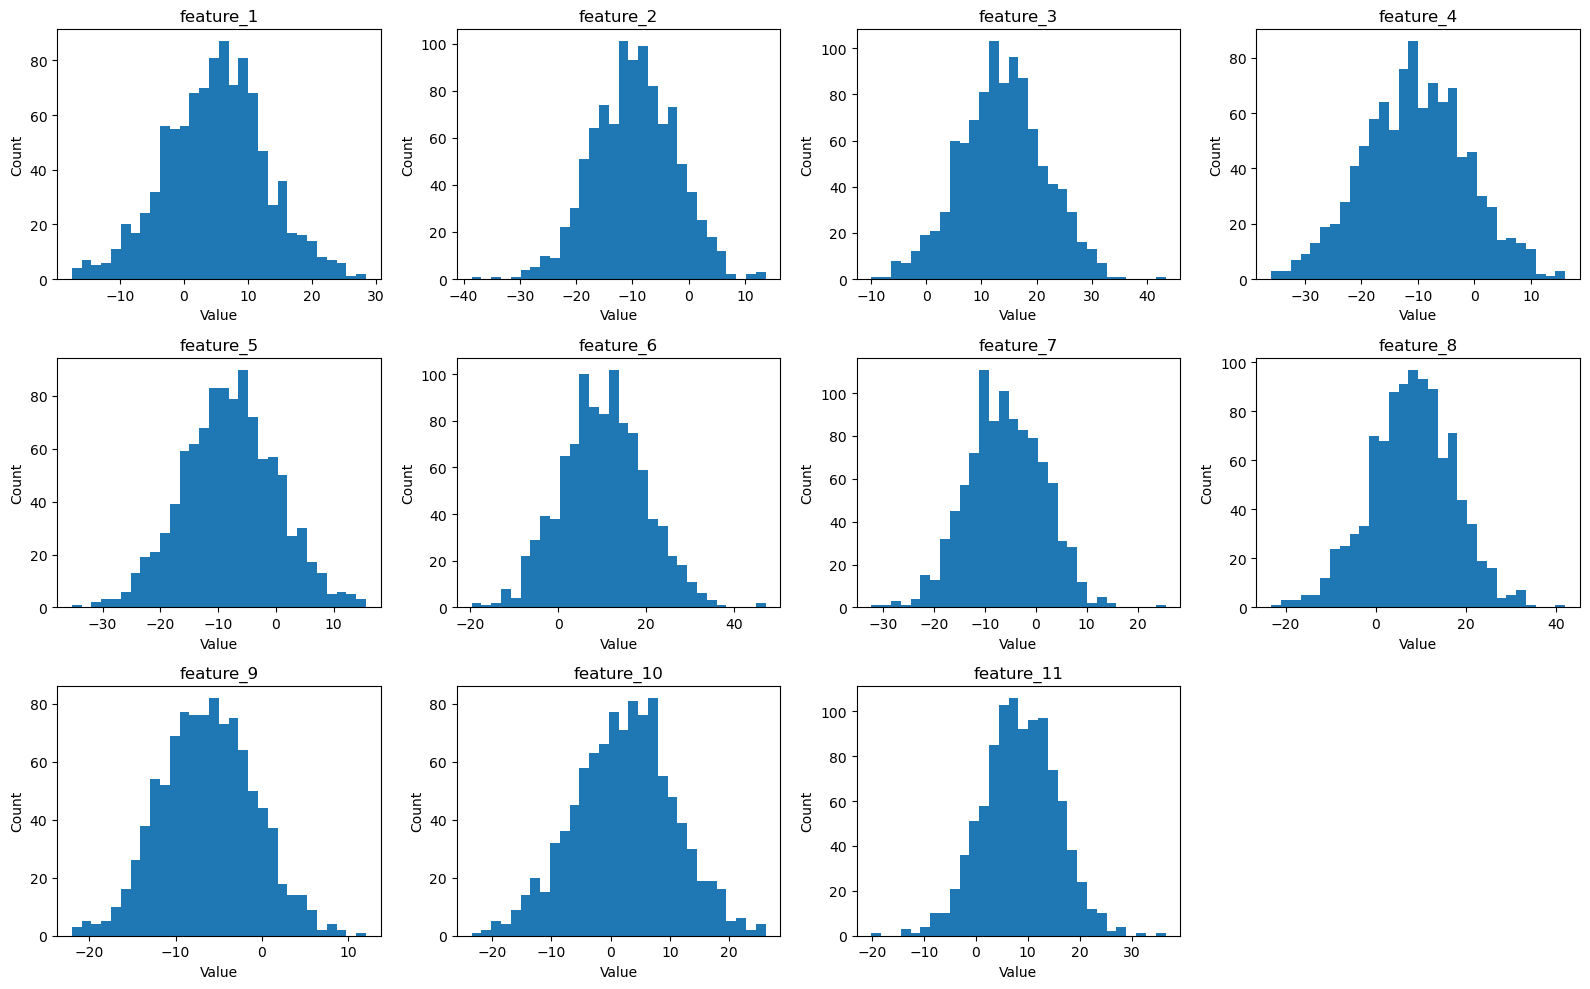

In [22]:
fig, axes = plt.subplots(3, 4, figsize=(16, 10))

for ax, feature in zip(axes.flat, feature_names):
    ax.hist(train_df[feature], bins=30)
    ax.set_title(feature)
    ax.set_xlabel("Value")
    ax.set_ylabel("Count")

for ax in axes.flat[len(feature_names):]:
    ax.remove()

plt.tight_layout()

**Note** This is anomaly detection, so an extreme value isn't automatically a bad data point. It may be precisely the kind of behavior the model needs to identify.

<a id="7"></a>
<h2 align="center">
  <span style="color: #440E03;">7. Feature scale comparisson </span>
</h2>

If the features have substantially different scales, that's a strong practical motivation for the preprocessing/scaling stage.

In [24]:
stats = train_df.agg(["mean", "std", "min", "max"]).T
stats

,mean,std,min,max
feature_1,4.939400,7.812549,-17.488978,28.384866
feature_2,-9.637268,7.297875,-38.593613,13.689702
feature_3,13.814707,7.653368,-9.913776,43.322411
feature_4,-10.464489,9.180867,-35.968341,16.082439
feature_5,-7.956229,8.082940,-35.351822,15.592370
feature_6,10.199504,9.469136,-19.691088,47.131732
feature_7,-6.019408,7.462519,-32.280955,25.473844
feature_8,7.969829,9.340749,-23.218312,41.978198
feature_9,-6.253182,5.446001,-22.039903,12.090256
feature_10,2.324513,8.417604,-23.459247,26.166271


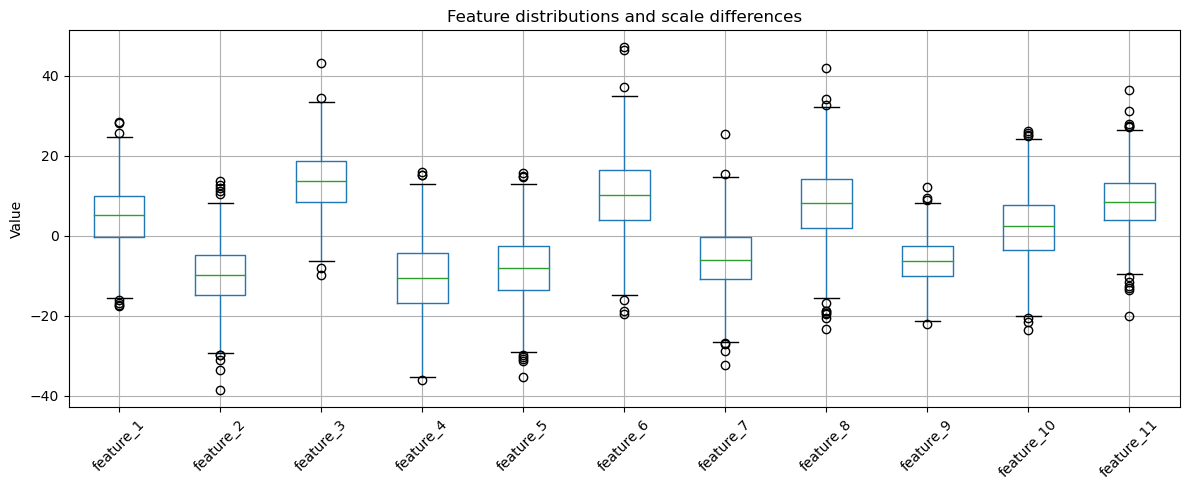

In [25]:
plt.figure(figsize=(12, 5))
train_df.boxplot()
plt.xticks(rotation=45)
plt.ylabel("Value")
plt.title("Feature distributions and scale differences")
plt.tight_layout()

The features exhibit moderately different scales. Their standard deviations range from approximately 5.45 to 9.47, while their observed ranges also vary considerably.

The differences are not extreme, but they are large enough to justify evaluating feature scaling, particularly for models and preprocessing methods that are sensitive to feature magnitude.

Therefore, scaling will be treated as a modeling choice to evaluate rather than an assumption imposed solely from the descriptive statistics.

<a id="8"></a>
<h2 align="center">
  <span style="color: #440E03;">8. Correlation analysis</span>
</h2>


What we are looking for:

- strongly correlated variables
- potentially redundant features
- groups of related server measurements


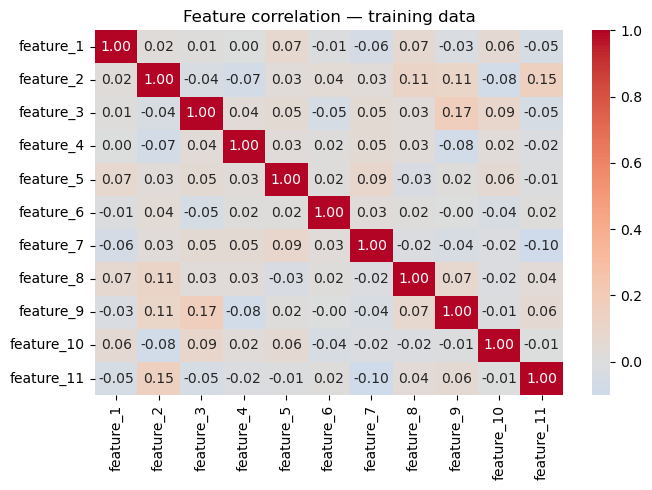

In [33]:
corr = train_df.corr()

plt.figure(figsize=(7, 5))
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Feature correlation — training data")
plt.tight_layout()

The Pearson correlation matrix shows generally weak **linear** relationships between the 11 features. The largest absolute correlation is approximately 0.17 (`feature_3` and `feature_9`), while most feature pairs have correlations close to zero.

This suggests that there are no obvious pairs of highly linearly redundant features in the training data. Therefore, the correlation analysis alone does not provide a strong reason to remove features.

The weak cross-feature correlations also mean that PCA should not be assumed to provide substantial dimensionality reduction. Its usefulness should instead be evaluated using the explained variance ratio.

It is important to distinguish cross-feature correlation from temporal dependence. This matrix measures relationships between different features across observations; it does not determine whether consecutive observations are related over time. Temporal dependence will therefore be investigated separately before deciding whether temporal windows or sequence models are justified.

<a id="9"></a>
<h2 align="center">
  <span style="color: #440E03;">9. Temporal Structure</span>
</h2>

The dataset does not provide an explicit timestamp in this experiment. Nevertheless, observations are assumed to be ordered according to their acquisition sequence, giving the dataset an implicit temporal index.

We are looking for:

- trends
- periodicity
- local changes
- bursts
- regime changes
- obvious serial dependence

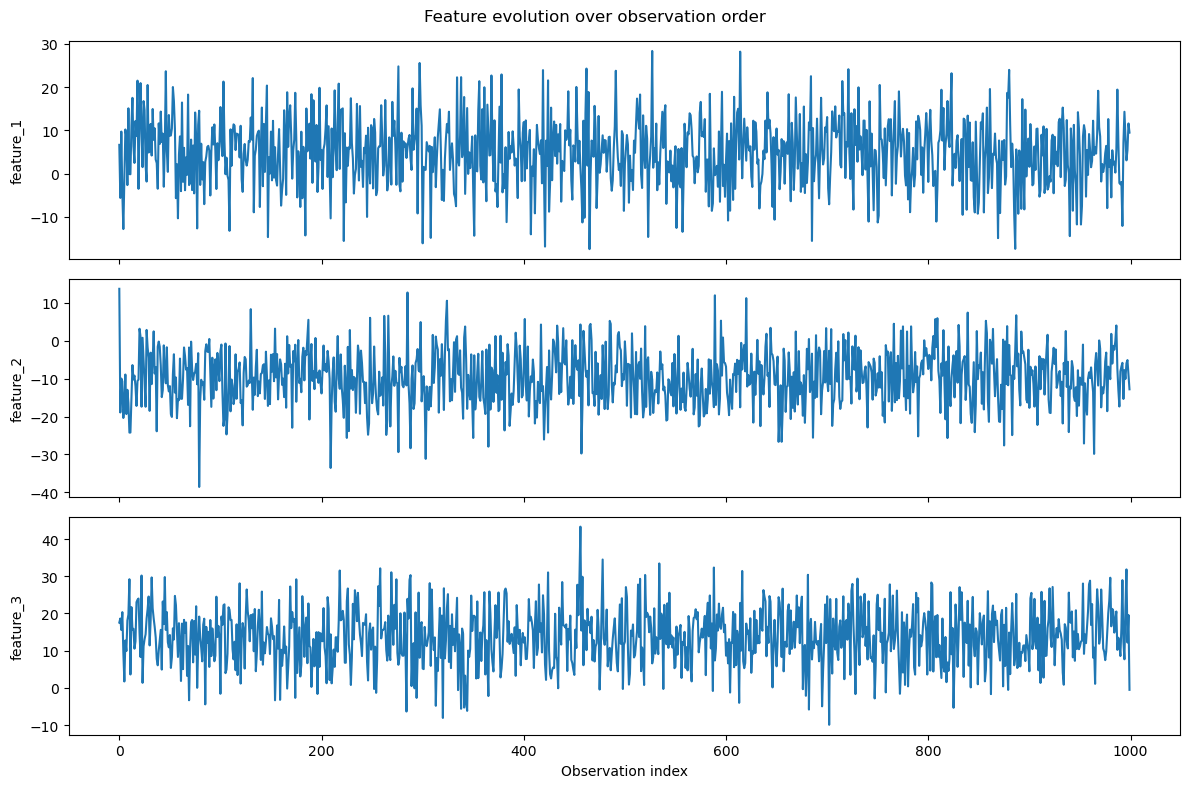

In [36]:
time = np.arange(len(X_train))

# plot a few representative features
fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)

for ax, feature in zip(axes, feature_names[:3]):
    ax.plot(time, train_df[feature])
    ax.set_ylabel(feature)

axes[-1].set_xlabel("Observation index")
fig.suptitle("Feature evolution over observation order")
plt.tight_layout()


<a id="9.1"></a>
<h3 align="left">
  <span style="color: #9C2007;">9.1. Autocorrelation</span>
</h3>

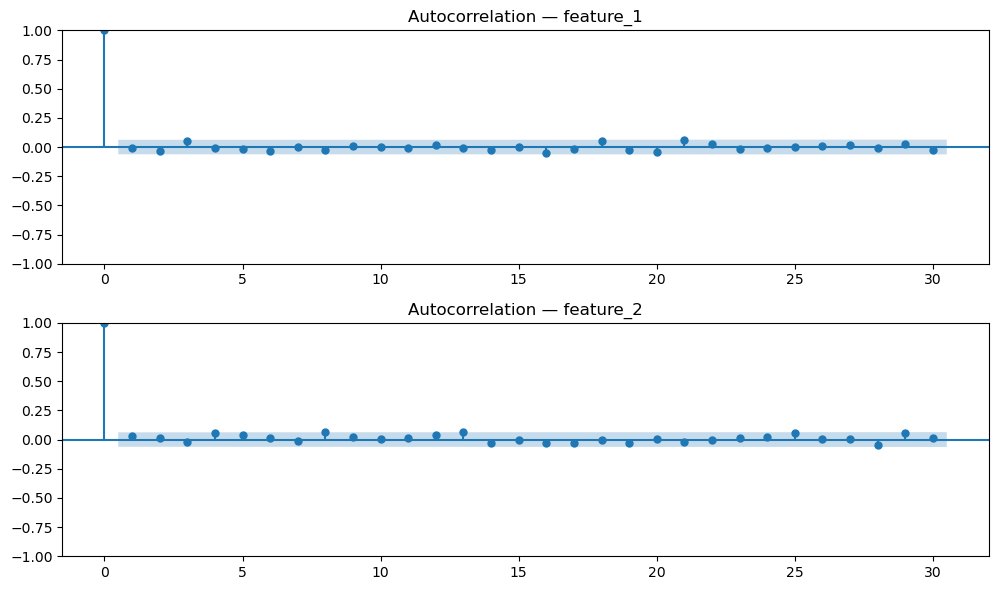

In [43]:
fig, axes = plt.subplots(2, 1, figsize=(10, 6))

for ax, feature in zip(axes, feature_names[:2]):
    plot_acf(
        train_df[feature],
        ax=ax,
        lags=30,
        title=f"Autocorrelation — {feature}",
    )

plt.tight_layout()

In [39]:
for feature in feature_names:
    corr_lag1 = train_df[feature].autocorr(lag=1)
    corr_lag5 = train_df[feature].autocorr(lag=5)

    print(
        f"{feature:12s} "
        f"lag-1={corr_lag1:.3f} "
        f"lag-5={corr_lag5:.3f}"
    )

feature_1    lag-1=-0.006 lag-5=-0.018
feature_2    lag-1=0.030 lag-5=0.037
feature_3    lag-1=0.006 lag-5=0.039
feature_4    lag-1=0.000 lag-5=-0.033
feature_5    lag-1=0.051 lag-5=0.033
feature_6    lag-1=0.020 lag-5=0.008
feature_7    lag-1=-0.040 lag-5=-0.009
feature_8    lag-1=-0.031 lag-5=-0.008
feature_9    lag-1=-0.052 lag-5=-0.020
feature_10   lag-1=-0.012 lag-5=-0.020
feature_11   lag-1=-0.004 lag-5=0.033


The temporal analysis provides little evidence of strong univariate temporal dependence in the training data.

Visual inspection of the feature trajectories shows predominantly noisy behavior without obvious trends or periodic patterns. This is consistent with the autocorrelation analysis, where ACF values remain close to zero across the evaluated lags.

The lag correlations are also very small. For example, the absolute lag-1 correlations range from approximately 0.000 to 0.052, while the lag-5 correlations remain below approximately 0.039 in absolute value.

Therefore, there is little evidence of strong **univariate linear temporal dependence** in the observed features.

This does not prove that the data is temporally independent. Nonlinear, multivariate, or anomaly-specific temporal relationships may still exist. Nevertheless, the current evidence does not strongly motivate temporal windows or sequence models on the basis of univariate temporal dependence alone.

Consequently, temporal windowing and sequence models will be treated as modeling choices to evaluate experimentally rather than assumptions directly supported by the EDA.

<a id="9.1.1"></a>
<h3 align="left">
  <span style="color: #C82909;">9.1.1. Windowing</span>
</h3>

Windowing may be useful to capture local temporal context that cannot be represented by individual observations alone.

In [51]:
def transform_with_labels(X, y, seq_len=5, stride=1):
        X = np.asarray(X)
        y = np.asarray(y)

        X_windows = []
        y_windows = []

        for i in range(
            0,
            len(X) - seq_len + 1,
            stride,
        ):
            X_windows.append(
                X[i:i + seq_len]
            )

            # Window is anomalous if any point is anomalous
            y_windows.append(
                int(np.any(y[i:i + seq_len] == 1))
            )

        return (
            np.stack(X_windows),
            np.asarray(y_windows),
        )
    
X_w, y_w = transform_with_labels(X_val, y_val)

X_w.shape, y_w.shape



((96, 5, 11), (96,))

In [52]:
# Original validation distribution
original_normal = np.sum(y_val == 0)
original_anomaly = np.sum(y_val == 1)

# Windowed validation distribution
window_normal = np.sum(y_w == 0)
window_anomaly = np.sum(y_w == 1)

print("Original validation set:")
print(f"  Samples: {len(y_val)}")
print(f"  Normal: {original_normal}")
print(f"  Anomalous: {original_anomaly}")
print(f"  Anomaly rate: {y_val.mean():.3f}")

print("\nWindowed validation set:")
print(f"  Windows: {len(y_w)}")
print(f"  Normal: {window_normal}")
print(f"  Anomalous: {window_anomaly}")
print(f"  Anomaly rate: {y_w.mean():.3f}")

Original validation set:
  Samples: 100
  Normal: 90
  Anomalous: 10
  Anomaly rate: 0.100

Windowed validation set:
  Windows: 96
  Normal: 58
  Anomalous: 38
  Anomaly rate: 0.396


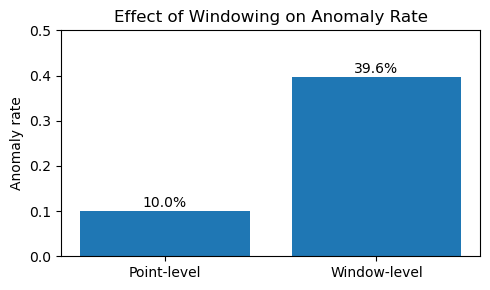

In [53]:
rates = [
    y_val.mean(),
    y_w.mean(),
]

labels = [
    "Point-level",
    "Window-level",
]

plt.figure(figsize=(5, 3))

bars = plt.bar(labels, rates)

plt.ylabel("Anomaly rate")
plt.ylim(0, 0.5)
plt.title("Effect of Windowing on Anomaly Rate")

for bar, rate in zip(bars, rates):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.01,
        f"{rate:.1%}",
        ha="center",
    )

plt.tight_layout()
plt.show()

Windowing substantially changes the effective label distribution. The anomaly rate increases from 10.0% at the point level to 39.6% at the window level.

This occurs because overlapping windows are labeled anomalous whenever they contain at least one anomalous observation. Consequently, a single point anomaly can propagate to multiple neighboring windows.

Therefore, window-level evaluation should be interpreted as a different prediction problem rather than as a direct representation of the original point-level distribution.

<a id="10"></a>
<h2 align="center">
  <span style="color: #440E03;">10. Validation anomaly distributions</span>
</h2>


In [56]:
print("Normal:", np.sum(y_val == 0))
print("Anomalous:", np.sum(y_val == 1))
print("Anomaly rate:", y_val.mean())

Normal: 90
Anomalous: 10
Anomaly rate: 0.1


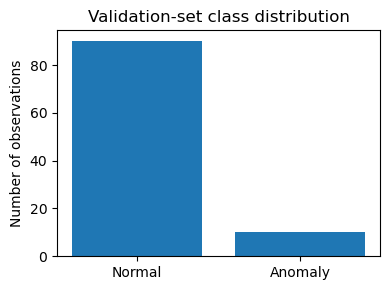

In [61]:
plt.figure(figsize=(4, 3))

plt.bar(
    ["Normal", "Anomaly"],
    [np.sum(y_val == 0), np.sum(y_val == 1)]
)

plt.ylabel("Number of observations")
plt.title("Validation-set class distribution")
plt.tight_layout()

The validation set is not simply another sample of the normal training distribution, it contains known anomalous observations and is therefore appropriate for evaluating candidate detectors and selecting operating parameters.

<a id="10.1"></a>
<h3 align="left">
  <span style="color: #9C2007;">10.1. Where are the anomalies?</span>
</h3>


This is particularly valuable given the implicit temporal ordering.

This tells us whether anomalies are:

- isolated
- clustered
- occurring in bursts

That's directly relevant to our windowing decision.

For example, if anomalies cluster around neighboring observations, a window can potentially capture contextual information that a point-wise detector cannot.

In [62]:
anomaly_indices = np.where(y_val == 1)[0]

print(anomaly_indices)

[ 0  3 19 27 38 59 71 88 91 92]


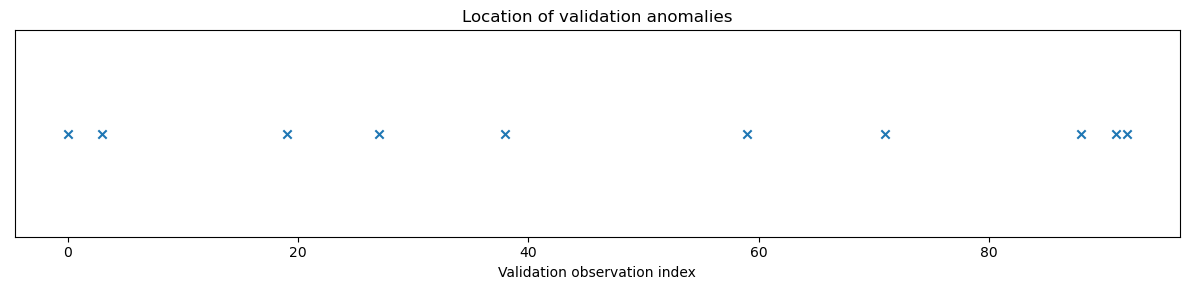

In [64]:
plt.figure(figsize=(12, 3))

plt.scatter(
    anomaly_indices,
    np.ones(len(anomaly_indices)),
    marker="x"
)

plt.yticks([])
plt.xlabel("Validation observation index")
plt.title("Location of validation anomalies")
plt.tight_layout()

The 10 anomalies are widely dispersed, but there is one clear local cluster at indices 88, 91, and 92. Most anomalies are isolated, suggesting that windowing may cause label propagation around isolated anomalies, while potentially providing useful temporal context for the clustered region.

<a id="10.2"></a>
<h3 align="left">
  <span style="color: #9C2007;">10.2. Compare normal vs anomalous distributions</span>
</h3>


This gives us a very useful visual answer:

    Which server variables appear to change when an anomaly occurs?

Because the validation set contains only 10 anomalies, feature-level comparisons should be treated as exploratory evidence rather than statistically conclusive. The plots are primarily used to identify potentially informative patterns and motivate subsequent model-based evaluation.

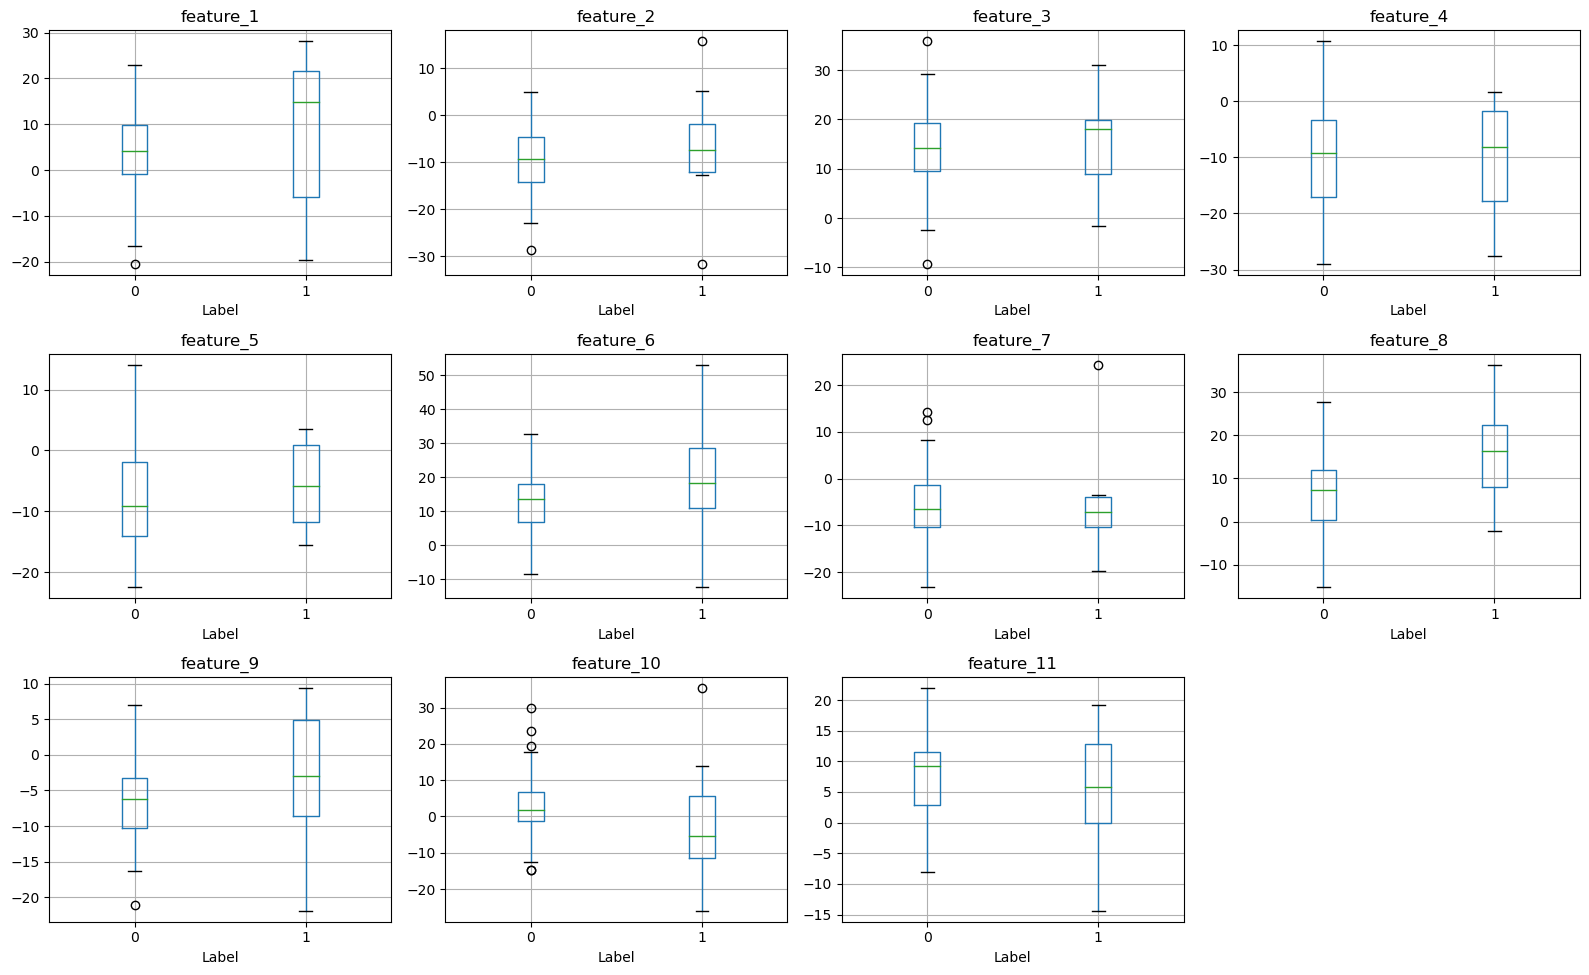

In [68]:
val_df = pd.DataFrame(X_val, columns=feature_names)
val_df["label"] = y_val

fig, axes = plt.subplots(3, 4, figsize=(16, 10))

for ax, feature in zip(axes.flat, feature_names):
    val_df.boxplot(
        column=feature,
        by="label",
        ax=ax
    )
    ax.set_title(feature)
    ax.set_xlabel("Label")

for ax in axes.flat[len(feature_names):]:
    ax.remove()

plt.suptitle("")
plt.tight_layout()

In [69]:
summary = (
    val_df
    .groupby("label")[feature_names]
    .agg(["median", "std", "min", "max"])
)

summary

feature_1                                  feature_2             \
          median        std        min        max    median        std   
label                                                                    
0       4.047130   8.330829 -20.522425  22.881904 -9.323999   6.692425   
1      14.758806  18.348614 -19.772252  28.086200 -7.387551  12.530266   

                             feature_3            ...  feature_9            \
             min        max     median       std  ...        min       max   
label                                             ...                        
0     -28.697342   4.850239  14.201051  8.000363  ... -21.132078  7.003553   
1     -31.671866  15.684168  18.068681  9.655939  ... -21.869114  9.351355   

      feature_10                                  feature_11             \
          median        std        min        max     median        std   
label                                                                     
0       1.737896   7.993571 -14.825341  29.927104   9.279231   6.124621   
1      -5.471973  17.441667 -25.928183  35.369189   5.780955  11.371485   

                             
             min        max  
label                        
0      -8.062086  21.949361  
1     -14.351686  19.123261  

[2 rows x 44 columns]

In [70]:
comparison = pd.DataFrame(index=feature_names)

for feature in feature_names:
    normal = val_df.loc[val_df["label"] == 0, feature]
    anomalous = val_df.loc[val_df["label"] == 1, feature]

    comparison.loc[feature, "normal_median"] = normal.median()
    comparison.loc[feature, "anomaly_median"] = anomalous.median()
    comparison.loc[feature, "median_difference"] = (
        anomalous.median() - normal.median()
    )
    comparison.loc[feature, "normal_std"] = normal.std()
    comparison.loc[feature, "anomaly_std"] = anomalous.std()

comparison.sort_values(
    "median_difference",
    key=abs,
    ascending=False,
)

,normal_median,anomaly_median,median_difference,normal_std,anomaly_std
feature_1,4.047130,14.758806,10.711675,8.330829,18.348614
feature_8,7.247453,16.410181,9.162728,8.176634,11.959765
feature_10,1.737896,-5.471973,-7.209869,7.993571,17.441667
feature_6,13.652683,18.162998,4.510315,8.995308,18.011634
feature_3,14.201051,18.068681,3.867630,8.000363,9.655939
feature_11,9.279231,5.780955,-3.498276,6.124621,11.371485
feature_5,-9.112624,-5.822047,3.290577,7.796110,7.267248
feature_9,-6.225099,-3.022925,3.202174,5.415421,10.795750
feature_2,-9.323999,-7.387551,1.936448,6.692425,12.530266
feature_4,-9.267220,-8.137428,1.129792,8.818371,10.598412


Several features show apparent distribution shifts between normal and anomalous observations, particularly feature_1, feature_8, and feature_10 (largest median shifts, 10.71, 9.16 and -7.20 respectively). However, the small number of anomalies makes these differences exploratory rather than conclusive, so feature-level separation should be evaluated through the subsequent anomaly-detection models rather than used directly for feature selection.

<a id="10.3"></a>
<h3 align="left">
  <span style="color: #9C2007;">10.3. Anomalies over the feature space</span>
</h3>

PCA provides a low-dimensional visualization of the feature space. Some separation between normal and anomalous observations may be visible, although this visualization alone is insufficient to determine whether PCA improves anomaly detection.


Since there are only 11 dimensions, PCA is useful as visualization, even if PCA is also an optional model preprocessing step.

In [79]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np


def plot_pca_2d(X, y, title):
    """
    Standardize observations and visualize them in 2D PCA space.

    X can be 2D (samples, features) or 3D
    (windows, sequence_length, features).
    """
    X = np.asarray(X)
    y = np.asarray(y)

    # Represent each window as one observation
    if X.ndim == 3:
        X = X.reshape(X.shape[0], -1)

    X_scaled = StandardScaler().fit_transform(X)

    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X_scaled)

    plt.figure(figsize=(4, 3))

    for label, name in [(0, "Normal"), (1, "Anomaly")]:
        mask = y == label

        plt.scatter(
            X_pca[mask, 0],
            X_pca[mask, 1],
            label=name,
            alpha=0.7,
        )

    explained = pca.explained_variance_ratio_

    plt.xlabel(f"PC1 ({explained[0]:.1%})")
    plt.ylabel(f"PC2 ({explained[1]:.1%})")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()

    return pca, X_pca

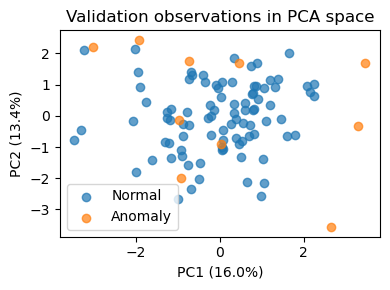

In [80]:
# Original point-level validation data
pca_val, X_val_pca = plot_pca_2d(
    X_val,
    y_val,
    "Validation observations in PCA space",
)

For the windowed dataset:

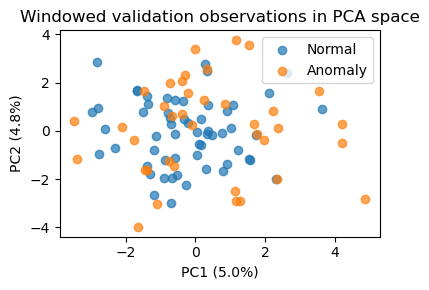

In [81]:
# Windowed validation data
pca_val_w, X_val_w_pca = plot_pca_2d(
    X_w,
    y_w,
    "Windowed validation observations in PCA space",
)

<a id="11"></a>
<h2 align="center">
  <span style="color: #440E03;">11. Summary</span>
</h2>

**Data characteristics:**

- 11 numerical server measurements.
- Training data consists primarily of normal observations and is therefore used to characterize normal behavior.
- Validation and test sets contain labeled anomalies.
- The observations have an implicit sequential ordering, although explicit timestamps are unavailable.
- Features may differ in scale and distribution, motivating configurable preprocessing.



| Observation                               | Modeling implication                               |
| ----------------------------------------- | -------------------------------------------------- |
| Different feature scales                  | Configurable feature scaling                       |
| Mostly normal training data               | Unsupervised/semi-supervised anomaly detection     |
| Labeled validation anomalies              | Model/threshold selection                          |
| Held-out labeled test set                 | Final unbiased evaluation                          |
| Sequential observation order              | Window-based modeling can be evaluated             |
| Potential temporal dependence             | AE/IsoForest vs sequence-aware models              |
| Only 11 features / 1,000 training samples | Keep architectures relatively small                |


